_Date: 23rd May 2026  
Authors: Lydia and Andre_

## Section 0 - Introduction

This notebook addresses the Fake News Detection challenge using Natural Language Processing (NLP) techniques. The goal is to build and compare classification models able to automatically distinguish fake news articles from real ones.

The pipeline follows these main steps:
1. **Exploratory Data Analysis** – understanding the dataset distributions, title and text lengths, and vocabulary.
2. **Feature Engineering** – constructing hand-crafted stylistic features and a combine the text fields into a single `content` field.
3. **Train / Test Split** – partitioning the data in a reproducible way in order to feed the classification models.
4. **Embedding** – representing text numerically via two strategies: TF-IDF Bag-of-Words (baseline) and a transformer-based Qwen2 dense embedding model.
5. **Classification** – training Naïve Bayes and Logistic Regression classifiers on each embedding.
6. **Model Comparison** – selecting the best performing combination.
7. **Predictions on unseen data** – applying the best model to a held-out validation set.
8. **Conclusions** - Draw conclusions based on the previous steps.

## Section 1 - Exploratory Data Analysis (EDA)
**Objective:** Understand the raw dataset before any transformation. The EDA will prevent data leakage and guides feature engineering decisions.

> **Dataset**: `data.csv` – contains `label` (0 = Fake, 1 = Real), `title`, `text`, `subject`, and `date` columns.

Key questions we answer in this section:
- Is the dataset balanced between fake (0) and real (1) labels?
- Does the `subject` feature perfectly separate the two classes?
- What is the date range and temporal density of articles?
- Do fake and real articles differ in title / text length?
- Are there duplicate records that must be removed?
- Are there any null values that require an action?
- Which words are most characteristic of each class?

#### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dateutil import parser
from wordcloud import WordCloud
from collections import Counter
import string
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
import torch
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

import re
import nltk
from nltk.corpus import wordnet
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')

#%pip uninstall transformers -y
#%pip install transformers==4.46.0

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

#### Load Dataset

In [ ]:
dataset = pd.read_csv('/content/data.csv')

#### Basic Information

In [ ]:
dataset.head()


# Result: Displays the first 5 rows of the dataset.
# We can see the 5 columns: label (0=Fake, 1=Real), title, text, subject, and date.
# The text column contains full article bodies which can be very long.

,label,title,text,subject,date
0,1,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,1,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,1,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
dataset.info()


# Result: Shows column names, non-null counts, and data types.
# All 5 columns are present. 'label' is int64; the rest are object (string).
# No missing values are apparent at this stage (non-null counts match total rows).

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39942 entries, 0 to 39941
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    39942 non-null  int64 
 1   title    39942 non-null  object
 2   text     39942 non-null  object
 3   subject  39942 non-null  object
 4   date     39942 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.5+ MB


In [ ]:
dataset.describe(include='all')


# Result: Summary statistics for all columns.
# 'label' has mean ~0.5, confirming the dataset is well balanced between fake and real.
# 'title', 'text', 'subject', 'date' columns show unique value counts and top frequencies.
# Notably, 'subject' has only a handful of unique categories, which is a red flag for potential leakage.

,label,title,text,subject,date
count,39942.000000,39942,39942,39942,39942
unique,NaN,36083,35977,6,2392
top,NaN,Factbox: Trump fills top jobs for his administ...,,politicsNews,"December 20, 2017"
freq,NaN,14,606,11272,182
mean,0.500701,NaN,NaN,NaN,NaN
std,0.500006,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN
25%,0.000000,NaN,NaN,NaN,NaN
50%,1.000000,NaN,NaN,NaN,NaN
75%,1.000000,NaN,NaN,NaN,NaN


#### Duplicate Records

In [ ]:
# Display the counting of duplicated observations
duplicates = dataset[dataset.duplicated()]
print("Duplicated Rows: " + str(len(duplicates)))


# Result: Prints the number of exact duplicate rows.
# 201 duplicated rows are found. These will be removed in Section 2 - Feature Engineering before modelling to avoid the same article appearing in both train and test sets.

Duplicated Rows: 201


#### Real vs Fake News Distribution

In [ ]:
# Display the distribution
dataset['label'].value_counts(normalize=True).mul(100).round(2).astype(str)+ '%'


# Result: Shows the percentage split between Fake (0) and Real (1) news.
# The dataset is almost perfectly balanced (~50% Fake / ~50% Real), meaning no class weighting or resampling techniques are needed.

,proportion
label,
1,50.07%
0,49.93%


#### Subject Distribution

In [ ]:
# Display the distribution
dataset['subject'].value_counts(normalize=True).mul(100).round(2).astype(str)+ '%'


# Result: Shows the percentage share of each subject category.
# 'politicsNews' and 'worldnews' together account for the majority of real articles, while categories like 'News', 'politics', 'left-news', etc. dominate the fake articles.

,proportion
subject,
politicsNews,28.22%
News,22.66%
worldnews,21.85%
politics,17.13%
left-news,6.21%
Government News,3.93%


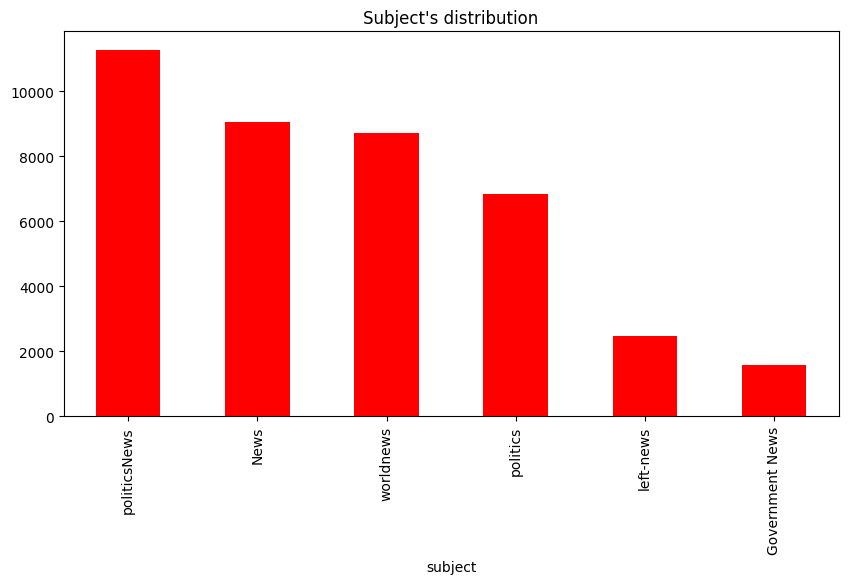

In [ ]:
# Plotting distribution
dataset['subject'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
    )

plt.title("Subject's distribution")

plt.show()


# Result: Bar chart of subject frequencies.
# 'politicsNews' and 'worldnews' dominate the distribution.
# The chart makes visually clear that subject categories are very unequal in size, further reinforcing that subject must not be used as a model feature.

#### Real vs Fake News distribution by subject

In [ ]:
# Display the distribution
dataset.pivot_table(index='label', columns='subject',  values="title", aggfunc='count', fill_value=0)


# Result: Cross-tabulation of label vs subject.
# The split is near-perfect:
#   - label=1 (Real) articles appear only in 'politicsNews' and 'worldnews'.
#   - label=0 (Fake) articles appear only in all other subject categories.
# This confirms that 'subject' is a perfect leakage predictor and must be excluded from all models, beside the fact this is NLP challenge.

subject,Government News,News,left-news,politics,politicsNews,worldnews
label,,,,,,
0,1570,9050,2482,6841,0,0
1,0,0,0,0,11272,8727


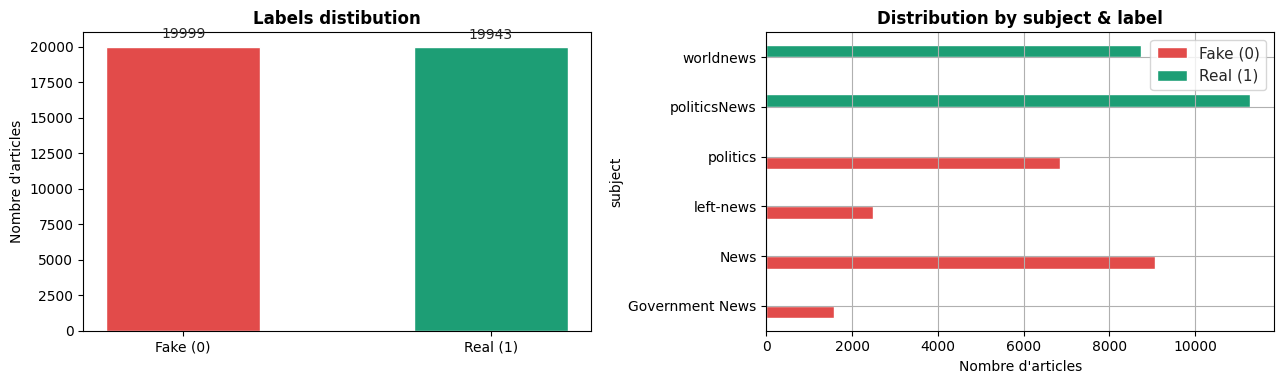

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.set_theme(style='whitegrid', palette='muted')
PALETTE = {'Fake (0)': '#E24B4A', 'Real (1)': '#1D9E75'}
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


# ── Label distribution ─────────────────────────────────────────────────
label_counts = dataset['label'].value_counts().rename({0:'Fake (0)', 1:'Real (1)'})
bars = axes[0].bar(label_counts.index, label_counts.values,
                   color=[PALETTE['Fake (0)'], PALETTE['Real (1)']], width=0.5, edgecolor='white')
axes[0].bar_label(bars, fmt='%d', padding=4, fontsize=10)
axes[0].set_title('Labels distibution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nombre d\'articles')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Fake (0)', 'Real (1)'])

# ── Subject distribution ───────────────────────────────────────────────
subj = dataset.groupby(['subject','label']).size().unstack(fill_value=0)
subj.plot(kind='barh', ax=axes[1],
          color=[PALETTE['Fake (0)'], PALETTE['Real (1)']], edgecolor='white')
axes[1].set_title('Distribution by subject & label', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nombre d\'articles')
axes[1].legend(['Fake (0)', 'Real (1)'])

plt.tight_layout()
plt.savefig('eda_01_distribution.png', bbox_inches='tight')
plt.show()


# Result: Two side-by-side charts
# Left chart — Label distribution: confirms the near 50/50 balance between Fake and Real articles. The dataset is well balanced.
# Right chart — Distribution by subject & label: visually confirms the perfect leakage, politicsNews and worldnews are exclusively Real and all other subjects are exclusively Fake.
# A model that knows the subject would have near-perfect accuracy without reading a single word. Subject feature has to be exclude.

#### Date analysis

In [ ]:
# Create a new column
dataset['length_date'] = dataset['date'].astype(str).str.len()

# Result: Adds a 'length_date' column measuring the character length of the raw date string.
# This is a diagnostic step to detect inconsistent date formats before parsin (e.g. short strings may indicate missing or malformed dates).

In [ ]:
dataset.describe()

# Result: Updated statistics now including 'length_date'.
# The date string lengths are fairly consistent, suggesting a uniform date format across the dataset.
# No extreme outliers in length_date, so the date column is likely well-formatted and parseable.

,label,length_date
count,39942.000000,39942.000000
mean,0.500701,14.858244
std,0.500006,2.874530
min,0.000000,9.000000
25%,0.000000,12.000000
50%,1.000000,15.000000
75%,1.000000,17.000000
max,1.000000,149.000000


Date Ranges:
 - Earliest Date: 2015-03-31 00:00:00
 - Latest Date:   2018-02-19 00:00:00
 - Time Span:      1056 days 00:00:00


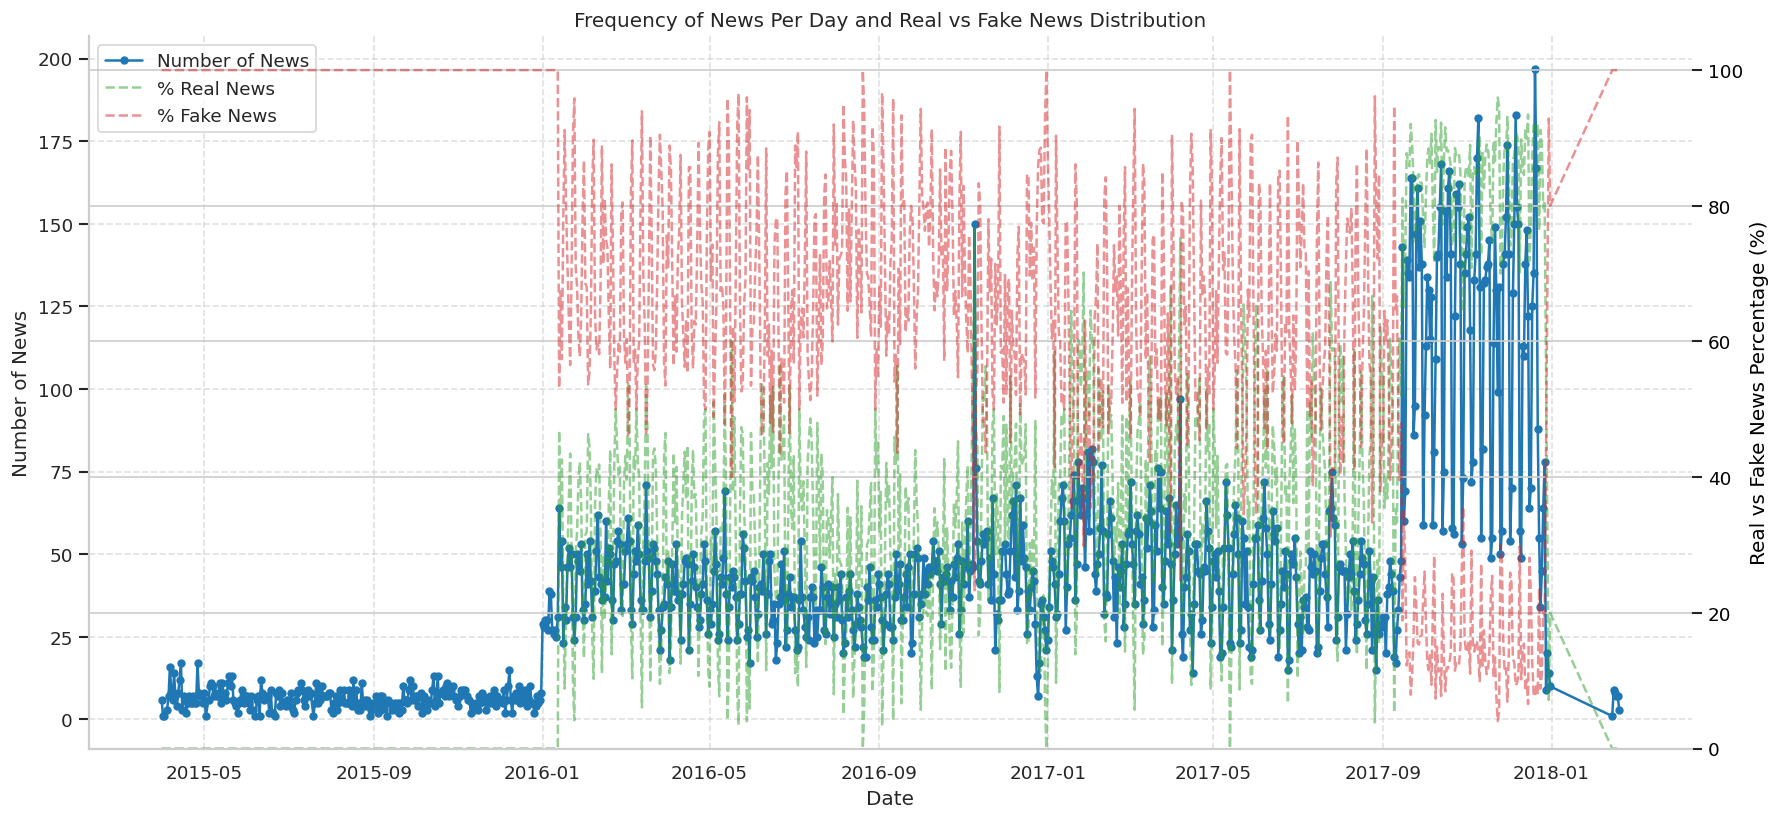

In [ ]:
# Create new column
def robust_date_parser(date_str):
    try:
        # dateutil.parser can handle 'Feb' and 'February' interchangeably
        return parser.parse(str(date_str))
    except (ValueError, TypeError):
        return pd.NaT

dataset['date'] = dataset['date'].apply(robust_date_parser)



# Check for any rows that failed to parse
failed_dates = dataset['date'].isna().sum()
if failed_dates > 0:
    print(f"Warning: {failed_dates} rows could not be parsed as dates.")


# Date Range
date_min = dataset['date'].min()
date_max = dataset['date'].max()

print(f"Date Ranges:")
print(f" - Earliest Date: {date_min}")
print(f" - Latest Date:   {date_max}")
print(f" - Time Span:      {date_max - date_min}")


# Plotting frequency of each day
daily_counts = dataset['date'].value_counts().sort_index()

label_percents = (
    dataset.groupby('date')['label']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100)

fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.plot(daily_counts.index, daily_counts.values, marker='o', linestyle='-', markersize=4, label='Number of News', color='tab:blue')
ax1.set_xlabel('Date')
ax1.set_ylabel('Number of News')
ax1.tick_params(axis='y')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2 = ax1.twinx()

ax2.plot(label_percents.index, label_percents[1], color='tab:green', linestyle='--', alpha=0.5, label='% Real News')
ax2.plot(label_percents.index, label_percents[0], color='tab:red', linestyle='--', alpha=0.5, label='% Fake News')

ax2.set_ylabel('Real vs Fake News Percentage (%)', color='black')
ax2.set_ylim(0, 105)
ax2.tick_params(axis='y', labelcolor='black')

plt.title('Frequency of News Per Day and Real vs Fake News Distribution')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.show()



# Result: Parses all date strings to proper datetime objects using a robust fallback parser.
# Prints how many rows failed to parse (expected: 0 or very few).
# The date range covers approximately 2015–2018, spanning the US political news cycle of that era.
# The dual-axis time series chart shows:
#   - Volume of news articles over time (blue line): peaks around major political events.
#   - % Real vs Fake per day (green/red dashed): relatively stable across time, confirming no strong temporal bias in the label distribution.
# Conclusion: 'date' carries weak predictive signal and is dropped in Section 2 - Feature Engineering to keep the model content only.


#### Title and Text Analysis

In [ ]:
# Create new columns
dataset['length_title'] = dataset['title'].astype(str).str.len()
dataset['length_text'] = dataset['text'].astype(str).str.len()


# Result: Adds two new columns measuring character length of the title and body text.
# These numeric features will be used to study length differences between fake and real articles, and to compute the title/text ratio in the next cell.

In [ ]:
dataset.describe()


# Result: Summary statistics now include length_title and length_text.
# Real articles tend to have longer text bodies on average than fake ones.
# Fake articles show higher variance in text length, of which some are very short, others very long.
# Title lengths are broadly similar between classes, but fake titles skew slightly longer.

,label,date,length_date,length_title,length_text
count,39942.000000,39934,39942.000000,39942.000000,39942.000000
mean,0.500701,2017-02-10 18:00:57.334602240,14.858244,79.774723,2384.637875
min,0.000000,2015-03-31 00:00:00,9.000000,8.000000,1.000000
25%,0.000000,2016-07-31 00:00:00,12.000000,63.000000,1259.000000
50%,1.000000,2017-03-15 00:00:00,15.000000,73.000000,2197.000000
75%,1.000000,2017-10-03 00:00:00,17.000000,90.000000,3069.000000
max,1.000000,2018-02-19 00:00:00,149.000000,286.000000,49705.000000
std,0.500006,NaN,2.874530,24.811136,1765.895463


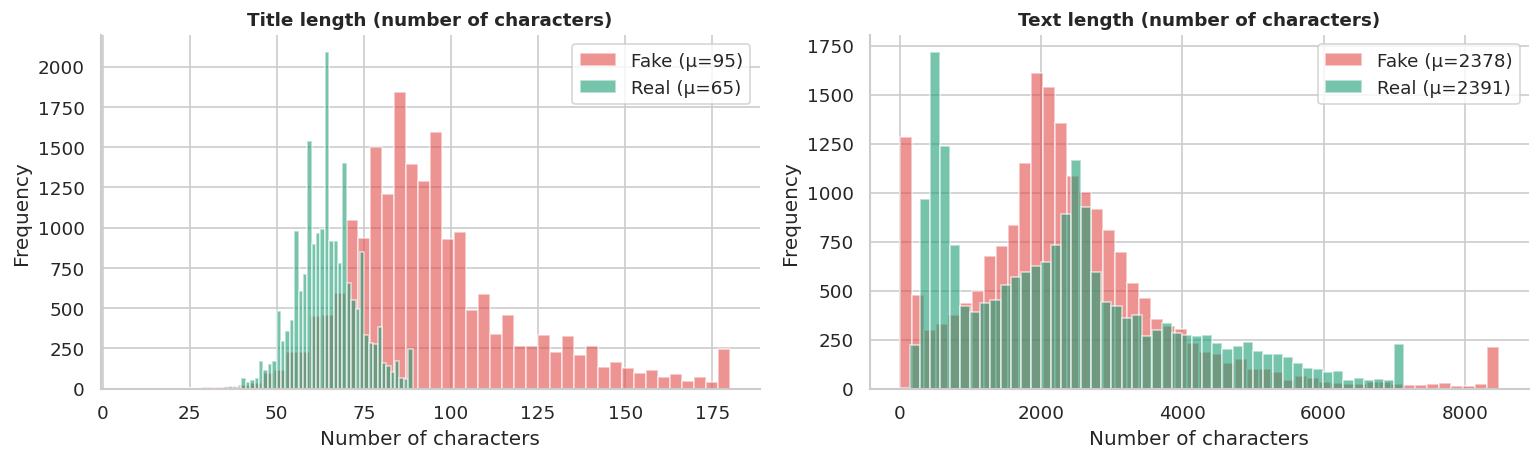

      length_title                                             length_text                                                      
             count  mean   std   min   25%   50%    75%    max       count    mean     std  min     25%     50%     75%      max
label                                                                                                                           
0          19943.0  95.0  26.2   8.0  79.0  90.0  104.0  286.0     19943.0  2378.0  1832.9  1.0  1498.0  2176.0  2961.0  49705.0
1          19999.0  64.6   9.2  26.0  59.0  64.0   70.0  133.0     19999.0  2391.3  1696.5  1.0   899.5  2231.0  3254.5  29781.0


In [ ]:
# Text Length and Title Length
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in zip(axes,
                           ['length_title', 'length_text'],
                           ['Title length (number of characters)', 'Text length (number of characters)']):
    for lbl, color in [(0, PALETTE['Fake (0)']), (1, PALETTE['Real (1)'])]:
        subset = dataset[dataset['label'] == lbl][col]
        ax.hist(subset.clip(upper=subset.quantile(0.99)),
                bins=50, alpha=0.6, color=color,
                label=f"{'Fake' if lbl==0 else 'Real'} (μ={subset.mean():.0f})")
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Number of characters')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.savefig('eda_02_lengths.png', bbox_inches='tight')
plt.show()

print(dataset.groupby('label')[['length_title','length_text']].describe().round(1).to_string())


# Result: Two overlapping histograms (Fake in red, Real in green) for title and text lengths.
# Title length: distributions largely overlap, where title alone is not a strong discriminator.
# Text length: Real articles have a heavier right tail (longer articles), while Fake articles cluster around shorter lengths with more extreme outliers.
# The mean values printed below confirm Real news is consistently longer in body text.

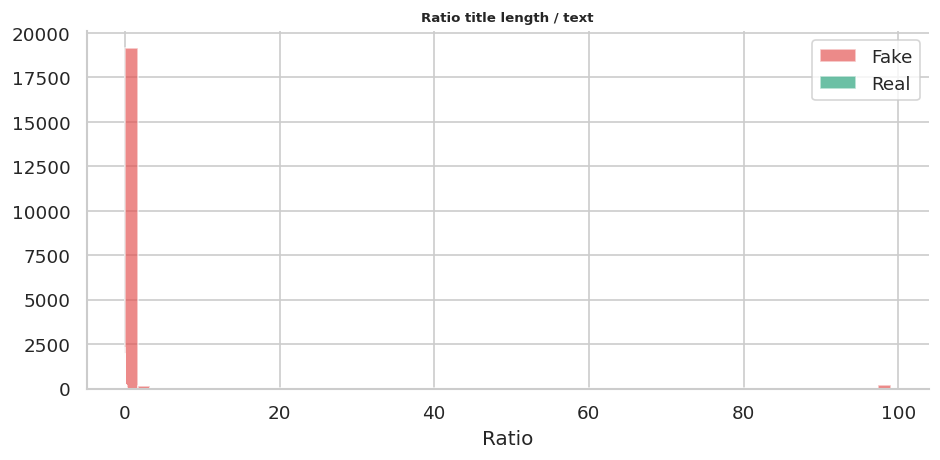

 A high ratio, very short text vs lenght title, is a potential signal of fake news 


In [ ]:
# Find a relevant ratio
dataset['ratio_title_text'] = dataset['length_title'] / dataset['length_text'].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(8, 4))
for lbl, color in [(0, PALETTE['Fake (0)']), (1, PALETTE['Real (1)'])]:
    vals = dataset[dataset['label']==lbl]['ratio_title_text'].dropna()
    ax.hist(vals.clip(0, vals.quantile(0.99)), bins=60, alpha=0.65,
            color=color, label=f"{'Fake' if lbl==0 else 'Real'}")
ax.set_title('Ratio title length / text', fontsize=8, fontweight='bold')
ax.set_xlabel('Ratio')
ax.legend()
plt.tight_layout()
plt.savefig('eda_03_ratio.png', bbox_inches='tight')
plt.show()

print(' A high ratio, very short text vs lenght title, is a potential signal of fake news ')


# Result: Histogram of the title-to-text length ratio split by label.
# Fake articles have a higher ratio (long title relative to short body text), a pattern consistent with clickbait style headlines with minimal article content.
# Real articles cluster at lower ratios, reflecting longer, more detailed body text.
# This ratio becomes the 'ratio_title_text' feature used in Section 2.

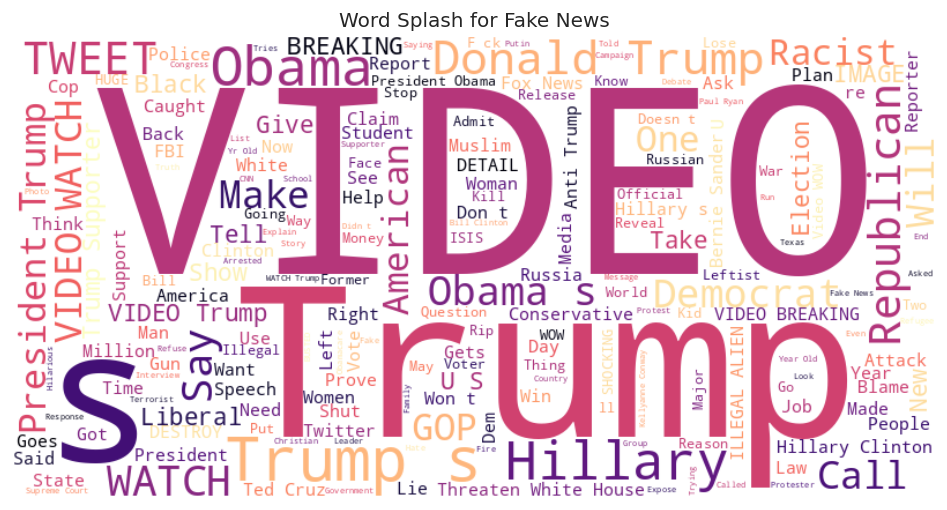

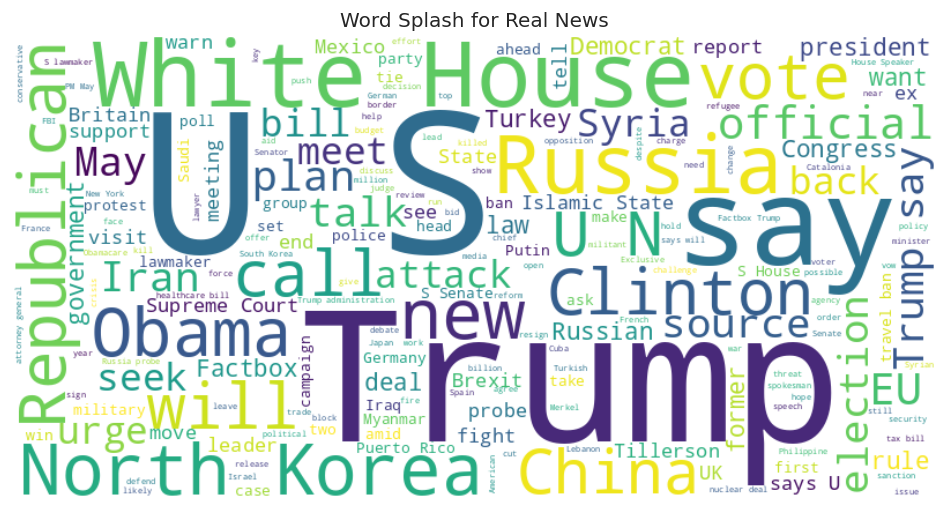

In [ ]:
# Most Common Words by Real and Fake News
def create_word_splash(dataset, label_val, title_text):
    text = " ".join(dataset[dataset['label'] == label_val]['title'].astype(str))

    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='magma' if label_val == 0 else 'viridis'
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"Word Splash for {title_text}")
    plt.axis('off')
    plt.show()

create_word_splash(dataset, 0, "Fake News")
create_word_splash(dataset, 1, "Real News")


# Result: Two word clouds generated from article titles, one per class.
# FAKE NEWS word cloud: dominated by names like 'Trump', 'Clinton', 'Obama' used in provocative contexts, alongside sensationalist terms. Reflects partisan and emotionally charged language.
# REAL NEWS word cloud: dominated by institutional terms, 'Reuters', 'White House', 'U.S.', 'North Korea', 'Senate' reflect factual, source attributed reporting.

### Section 1 – Key Takeaways

| Finding | Impact |
|---------|--------|
| Dataset is well-balanced (~50 / 50 fake vs real) | No class-weighting needed |
| `subject` is a perfect leakage predictor (politicsNews/worldnews ↔ Real; rest ↔ Fake) | Must be excluded from features |
| Articles span roughly 2015-2018 with variable daily density | Date usable as a weak temporal feature but risky |
| Fake news titles tend to be slightly longer and more sensational | Motivates stylometric features in Section 2 |
| 201 duplicated rows detected | Will be dropped before modelling |
| Word clouds reveal distinctive vocabulary per class (e.g. *Reuters*, *White House* in Real; *Clinton*, *Obama* sensationally in Fake) | Supports TF-IDF discriminative power |

## Section 2 - Feature Engineering

**Objective:** Transform raw text columns into a richer representation by cleaning the data and adding interpretable hand-crafted stylometric features that capture writing style patterns known to differ between fake and real news.

Steps performed:
- Remove the 201 duplicated records identified in Section 1 - EDA.
- Concatenate `title` + `text` into a single `content` feature. The new feature will be the primary input to the models.
- Drop `subject` to avoid leakage and `date` to keep the approach text only.
- Engineer 10 stylometric features to capture sensationalism, clickbait language, punctuation density, text-to-title length ratio, and source signals. These features are not fed into the text preprocessing pipelines below. They are kept as an optional enrichment layer and could be used in a future tree-based model where interpretability matters.

In [ ]:
# Remove duplicated observations
dataset = dataset.drop_duplicates()

# Concatenate Title and Text
dataset['content'] = dataset['title'] + " " + dataset['text']


Stylometric features and hypotheses :

*  is_all_caps_title	: sensationnalisme => Fake
*  caps_ratio_title	: Signal intensity => Fake
*  has_breaking : BREAKING Fake emergency => Fake
*  has_exclamation	: sensationnalisme => Fake
*  has_question	: ? in the title, Conspiracy framing => Fake
*  clickbait_words :	Nb of clickbait words in title,	Score clickbait => Fake
*  pct_punct_title	: % lot of ponctuationin title => Fake
*  nb_words_title : Long titles => Fake
*  nb_words_text	: Long texts => Real
*  starts_reuters : Text start with 'WASHINGTON (Reuters)'	official source => Real

In [ ]:
CLICKBAIT_VOCAB = [
    'shocking', 'unbelievable', 'you won\'t believe', 'must see', 'secret',
    'exposed', 'destroyed', 'blasts', 'slams', 'obliterates', 'pathetic',
    'witch hunt', 'radical', 'extreme', 'freaks', 'hack', 'fake', 'hoax'
]

def engineer_features(df):
    df = df.copy()
    t = df['title'].astype(str)
    x = df['text'].astype(str)

    # ── Title : style ─────────────────────────────────────────────────
    df['is_all_caps_title']  = (t == t.str.upper()).astype(int)
    df['caps_ratio_title']   = t.apply(
        lambda s: sum(1 for c in s if c.isupper()) / max(len(s), 1)
    )
    df['has_breaking']       = t.str.contains(r'BREAKING', case=True, na=False).astype(int)
    df['has_exclamation']    = t.str.contains('!', na=False).astype(int)
    df['has_question']       = t.str.contains(r'\?', na=False).astype(int)
    df['nb_words_title']     = t.str.split().str.len()
    df['pct_punct_title']    = t.apply(
        lambda s: sum(1 for c in s if c in string.punctuation) / max(len(s), 1)
    )
    df['clickbait_score']    = t.str.lower().apply(
        lambda s: sum(1 for w in CLICKBAIT_VOCAB if w in s)
    )

    # ── Text ──────────────────────────────────────────────────────────
    df['nb_words_text']      = x.str.split().str.len()
    df['starts_reuters']     = x.str.startswith('WASHINGTON (Reuters)').astype(int)

    # ── Ratio title / text ───────────────────────────────────────────
    df['ratio_title_text']   = df['length_title'] / df['length_text'].replace(0, np.nan)

    return df

dataset = engineer_features(dataset)
print('Features created :', [c for c in dataset.columns if c not in ['label','title','text','subject','date']])
dataset[['label','is_all_caps_title','has_breaking','starts_reuters','clickbait_score']].head(20)

Features created : ['length_date', 'length_title', 'length_text', 'ratio_title_text', 'content', 'is_all_caps_title', 'caps_ratio_title', 'has_breaking', 'has_exclamation', 'has_question', 'nb_words_title', 'pct_punct_title', 'clickbait_score', 'nb_words_text', 'starts_reuters']


,label,is_all_caps_title,has_breaking,starts_reuters,clickbait_score
0,1,0,0,1,0
1,1,0,0,1,0
2,1,0,0,1,0
3,1,0,0,1,0
4,1,0,0,0,0
5,1,0,0,0,0
6,1,0,0,0,0
7,1,0,0,0,0
8,1,0,0,0,0
9,1,0,0,1,0


## Section 3 - Split the dataset into train and test
**Objective:** Partition the cleaned dataset into training and test sets in a reproducible way, ensuring both splits reflect the overall label distribution.

- **Split ratio:** 80% train / 20% test — large enough training set for dense embeddings while keeping a meaningful held-out evaluation.
- **`random_state=42`** – ensures full reproducibility.
- **`stratify=y`** - ensures the split preserves the class proportions from the original dataset in both the train and test sets.
- The split is performed on `x = content` (concatenated title + text) with `y = label`.
- The same split indices are reused for both the TF-IDF and Qwen2 pipelines, enabling a fair comparison.

In [ ]:
# Split the dataset
X = dataset['content']
y = dataset['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}\n")
print(f"Train label distribution:\n{y_train.value_counts(normalize=True)}")

Train size: 31792, Test size: 7949

Train label distribution:
label
0    0.501761
1    0.498239
Name: proportion, dtype: float64


### Section 3 – Key Takeaways

The train / test split is stratified preserving the 50/50 label ratio in both subsets. All downstream embedding and classification steps strictly use `X_train` for fitting and `X_test` only for evaluation.

## Section 4.1 - Embedding - using Bag-of-Words and TF-IDF (Baseline)

**Objective:** Create a sparse, interpretable numerical representation of the text using the classic TF-IDF pipeline. This serves as the baseline against which the Qwen2 dense embeddings are compared.

Pipeline:
1. **Text normalisation** – lower-case, URL removal, digit removal, punctuation stripping.
2. **Tokenisation → Stop-word removal → POS-aware Lemmatization** using WordNet - reduces each word to its base grammatical form, guided by its part-of-speech tag for higher accuracy.
3. **CountVectorizer** (`max_df=0.7`, `min_df=2`) – builds the vocabulary and counts word occurrences. `max_df=0.7` removes words appearing in more than 70% of documents, which are considered too common to be discriminative. `min_df=2` removes extremely rare words.
4. **TF-IDF transformation** (`norm='l2'`, `smooth_idf=True`) – re-weights raw counts by inverse document frequency. `norm='l2` ensures all document vectors have unit length, making them comparable regardless of article length. `
smooth_idf=True` adds 1 to document frequencies to avoid division by zero on unseen terms.




In [ ]:
# Parts-Of-Speech (POS) Tagging
def get_wordnet_pos_from_tag(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

# NL Processing
def nl_processing(text):
    # Clean text
    text = str(text).lower()
    text = re.sub(r'https?://\S+', '', text)          # URLs
    text = re.sub(r'\d+', '', text)                   # chiffres
    text = re.sub(r'\.', '', text)                    # remove all dots
    text = re.sub(r'[^\w\s]', ' ', text)              # punctuation
    text = re.sub(r'\s+', ' ', text).strip()

    wordnet_lemma = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))

    # Tokenize
    tokens = word_tokenize(text)
    # Remove stop words and non-alphabetic tokens
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    # Lemmatize
    tagged = nltk.pos_tag(tokens)
    lemmas = [wordnet_lemma.lemmatize(token, get_wordnet_pos_from_tag(tag)) for token, tag in tagged]
    lemmas = ' '.join(lemmas)
    return lemmas

# New X variables
X_train_baseline = X_train.apply(nl_processing)
X_test_baseline = X_test.apply(nl_processing)


# Text to token matrix
count_vectorizer = CountVectorizer (
    lowercase=True,
    max_df=0.7,
    min_df=2)
X_train_baseline = count_vectorizer.fit_transform(X_train_baseline)
X_test_baseline = count_vectorizer.transform(X_test_baseline)
print(f"Count matrix shape: {X_train_baseline.shape}")

# TF-IDF transformation
tfidf_transformer = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True)
X_train_baseline = tfidf_transformer.fit_transform(X_train_baseline)
X_test_baseline = tfidf_transformer.transform(X_test_baseline)
print(f"TF-IDF matrix shape: {X_train_baseline.shape}")

Count matrix shape: (31792, 59267)
TF-IDF matrix shape: (31792, 59267)


## Section 4.2 - Embedding - using Qwen2 model

**Objective:** Produce dense, context-aware sentence embeddings using the **Alibaba-NLP/gte-Qwen2-1.5B-instruct** model. This model belongs to the GTE (General Text Embedding) family and is built on the Qwen2-1.5B LLM, adapted for embedding through bidirectional attention mechanisms and specialised multilingual training across diverse domains.

Key design choices:
- **Masked mean pooling** over the last hidden state: padding tokens are excluded so the document vector is not diluted.
- **Bidirectional attention** — unlike standard causal LLMs, the model attends to the full context in both directions, making it significantly better suited for representing a whole document as a single vector.
- **Truncation to 3 200 tokens** – a practical infrastructure choice driven by GPU memory constraints. The model supports up to 32,000 tokens natively, so this truncation covers the vast majority of articles while staying within memory limits.
- **Batch inference** (`batch_size=8`) with `tqdm` progress tracking.
- Output: a **fixed-size 1 536-dimensional dense vector** per document, capturing semantic meaning beyond surface vocabulary.

> This approach is significantly more expressive than TF-IDF but also more computationally expensive. A GPU (`cuda`) is strongly recommended for the full dataset.

In [ ]:
# Embedding model
model_name = "Alibaba-NLP/gte-Qwen2-1.5B-instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModel.from_pretrained(model_name, trust_remote_code=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

def get_qwen_embeddings(texts, batch_size=8):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(
            batch, padding=True, truncation=True, max_length=3200,
            return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            outputs = model(**encoded)
            attention_mask = encoded["attention_mask"] # values 1 for real, 0 for padding without padding
            token_embeds = outputs.last_hidden_state # includes the padding
            mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeds.size()).float() # get the same size as token_embeds
            mean_embeds = torch.sum(token_embeds * mask_expanded, 1) / torch.clamp(mask_expanded.sum(1), min=1e-9) # calculation to get one vector per document, instead of one vector per token
            embeddings.append(mean_embeds.cpu().numpy())
    return np.vstack(embeddings)

# Encode train and test sets
X_train_qwen = get_qwen_embeddings(X_train.tolist())
X_test_qwen = get_qwen_embeddings(X_test.tolist())

print(f"\nQwen embeddings shape: {X_train_qwen.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.11G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 994/994 [08:22<00:00,  1.98it/s]


Qwen embeddings shape: (31792, 1536)


In [ ]:
#free memory after embedding using GPU
"""del model
del tokenizer
torch.cuda.empty_cache()

print("GPU memory freed ✅")"""

'del model\ndel tokenizer\ntorch.cuda.empty_cache()\n\nprint("GPU memory freed ✅")'

## Section 5.1 - Classification model - NaiveBayes

**Objective:** Train a Gaussian Naïve Bayes classifier on both embedding representations and compare results.

Why Naïve Bayes?
- Extremely fast to train and predict.
- GaussianNB assumes features follow a normal distribution, making it compatible with both TF-IDF and Qwen2 dense embeddings.
- Provides a simple probabilistic baseline before investing in more complex classifiers.

In [ ]:
# Naive Bayes on Baseline embeddings
nb_baseline = GaussianNB()
nb_baseline.fit(X_train_baseline.toarray(), y_train)
y_pred_nb_baseline = nb_baseline.predict(X_test_baseline.toarray())
print("=== Naive Bayes + Baseline embeddings ===")
print(classification_report(y_test, y_pred_nb_baseline, target_names=['Fake', 'Real'], digits=3))


=== Naive Bayes + Baseline embeddings ===
              precision    recall  f1-score   support

        Fake      0.914     0.875     0.894      3988
        Real      0.880     0.917     0.898      3961

    accuracy                          0.896      7949
   macro avg      0.897     0.896     0.896      7949
weighted avg      0.897     0.896     0.896      7949



In [ ]:
# Naive Bayes on Qwen embeddings
nb_qwen = GaussianNB()
nb_qwen.fit(X_train_qwen, y_train)
y_pred_nb_qwen = nb_qwen.predict(X_test_qwen)
print("=== Naive Bayes + Qwen embeddings ===")
print(classification_report(y_test, y_pred_nb_qwen, target_names=['Fake', 'Real'], digits=3))

=== Naive Bayes + Qwen embeddings ===
              precision    recall  f1-score   support

        Fake      0.934     0.923     0.928      3988
        Real      0.923     0.934     0.928      3961

    accuracy                          0.928      7949
   macro avg      0.928     0.928     0.928      7949
weighted avg      0.928     0.928     0.928      7949



## Section 5.2 - Classification model - Logistic Regression

**Objective:** Train a Logistic Regression classifier on both embedding representations and compare the results.

Why Logistic Regression?
- Produces calibrated probability scores, not just hard labels.
- L2 regularisation prevents overfitting on high-dimensional TF-IDF features.
- When paired with Qwen2 embeddings, it acts as a lightweight linear probe that tests how linearly separable the semantic space is.

> `max_iter=1000` ensures convergence on the large TF-IDF vocabulary.\
> `random_state=42` ensures full reproducibility.

In [ ]:
# Logistic Regression on Baseline embeddings
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train_baseline, y_train)
y_pred_lr_baseline = lr_baseline.predict(X_test_baseline)
print("=== Logistic Regression + Baseline embeddings ===")
print(classification_report(y_test, y_pred_lr_baseline, target_names=['Fake', 'Real'], digits=3))



=== Logistic Regression + Baseline embeddings ===
              precision    recall  f1-score   support

        Fake      0.987     0.981     0.984      3988
        Real      0.981     0.987     0.984      3961

    accuracy                          0.984      7949
   macro avg      0.984     0.984     0.984      7949
weighted avg      0.984     0.984     0.984      7949



In [ ]:
# Logistic Regression on Qwen embeddings
lr_qwen = LogisticRegression(max_iter=1000, random_state=42)
lr_qwen.fit(X_train_qwen, y_train)
y_pred_lr_qwen = lr_qwen.predict(X_test_qwen)
print("=== Logistic Regression + Qwen embeddings ===")
print(classification_report(y_test, y_pred_lr_qwen, target_names=['Fake', 'Real'], digits=3))

=== Logistic Regression + Qwen embeddings ===
              precision    recall  f1-score   support

        Fake      0.998     0.999     0.999      3988
        Real      0.999     0.998     0.999      3961

    accuracy                          0.999      7949
   macro avg      0.999     0.999     0.999      7949
weighted avg      0.999     0.999     0.999      7949



## Section 6 - Model comparison

**Objective:** Aggregate and compare the performance of all four model combinations (2 embedding strategies x 2 classifiers) and select the best pipeline for deployment on test data.

Evaluation metrics:
- **Accuracy** – overall correct predictions, and the primary selection criterion.
- **Precision / Recall / F1-score** – per-class breakdown.

In [ ]:
#_______metrics table comparison____________

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

metrics_df = pd.DataFrame({
    'Model': [
        'Naive Bayes Baseline',
        'Naive Bayes Qwen',
        'Logistic Regression Baseline',
        'Logistic Regression Qwen'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb_baseline),
        accuracy_score(y_test, y_pred_nb_qwen),
        accuracy_score(y_test, y_pred_lr_baseline),
        accuracy_score(y_test, y_pred_lr_qwen)
    ],
    'Precision': [
        precision_score(y_test, y_pred_nb_baseline, average='weighted'),
        precision_score(y_test, y_pred_nb_qwen, average='weighted'),
        precision_score(y_test, y_pred_lr_baseline, average='weighted'),
        precision_score(y_test, y_pred_lr_qwen, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_nb_baseline, average='weighted'),
        recall_score(y_test, y_pred_nb_qwen, average='weighted'),
        recall_score(y_test, y_pred_lr_baseline, average='weighted'),
        recall_score(y_test, y_pred_lr_qwen, average='weighted')
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_nb_baseline, average='weighted'),
        f1_score(y_test, y_pred_nb_qwen, average='weighted'),
        f1_score(y_test, y_pred_lr_baseline, average='weighted'),
        f1_score(y_test, y_pred_lr_qwen, average='weighted')
    ]
})

metrics_df.round(3)


,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes Baseline,0.896,0.897,0.896,0.896
1,Naive Bayes Qwen,0.928,0.928,0.928,0.928
2,Logistic Regression Baseline,0.984,0.984,0.984,0.984
3,Logistic Regression Qwen,0.999,0.999,0.999,0.999


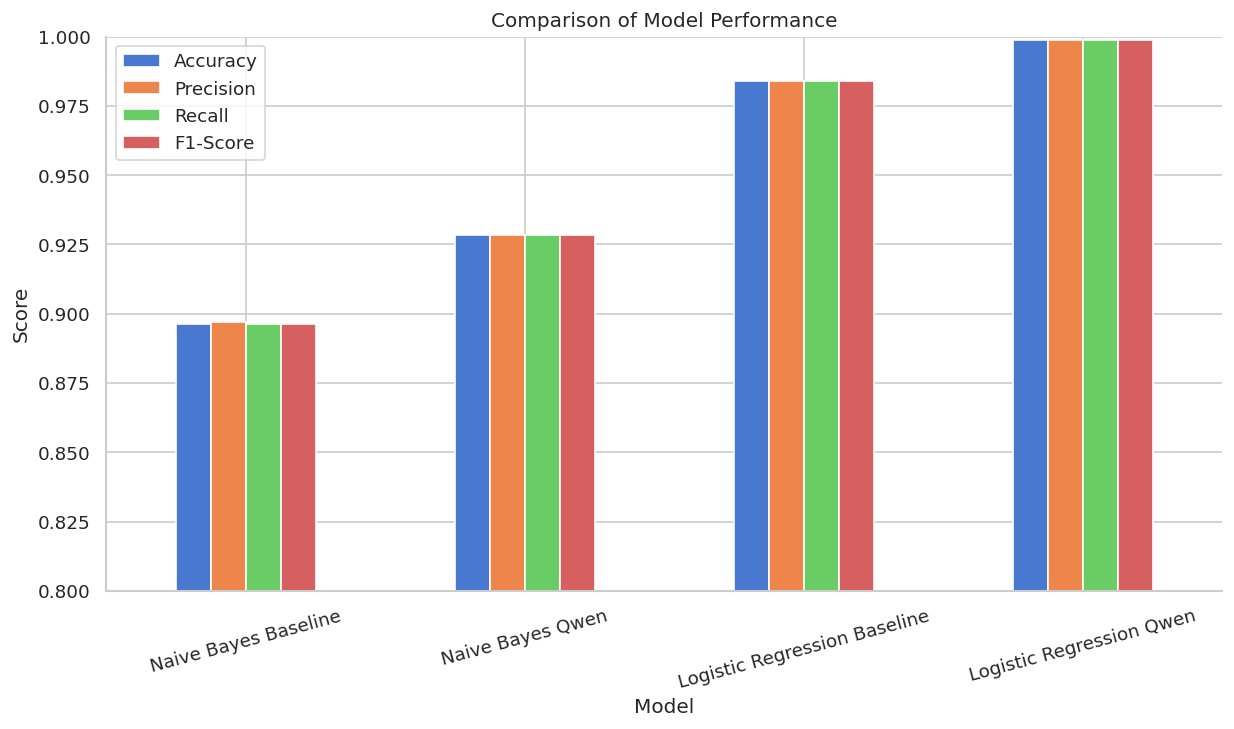

In [ ]:
#_________metrics bar chart__________________

metrics_df.set_index('Model').plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Comparison of Model Performance")

plt.ylabel("Score")

plt.ylim(0.8, 1.0)

plt.xticks(rotation=15)

plt.show()

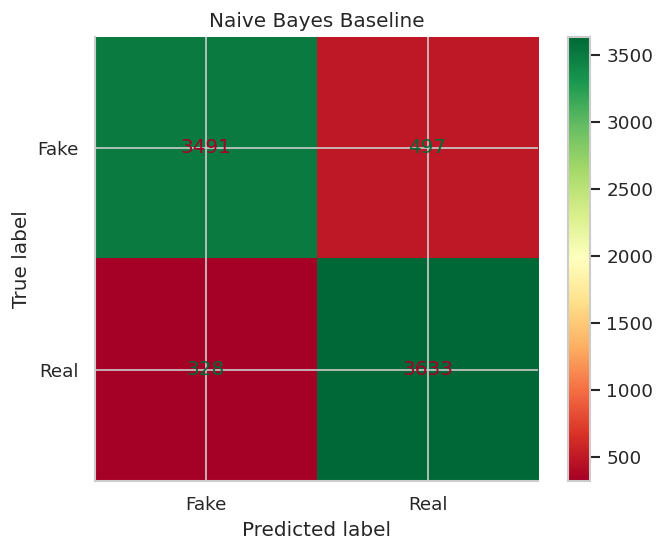

In [ ]:
#______Confusion matrix Naive Bayses Baseline________


cm_nb_baseline = confusion_matrix(
    y_test,
    y_pred_nb_baseline
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb_baseline,
    display_labels=['Fake', 'Real']

)

disp.plot(cmap='RdYlGn')

plt.title("Naive Bayes Baseline")

plt.show()

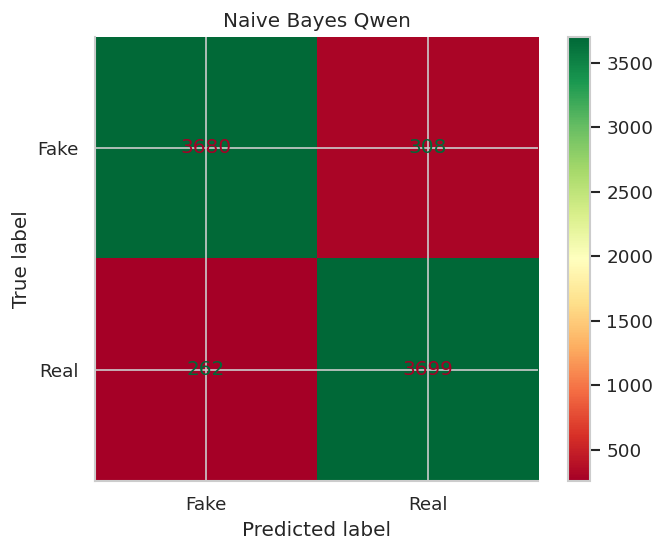

In [ ]:
#______Confusion matrix Naive Bayses + Qwen ________

cm_nb_qwen = confusion_matrix(
    y_test,
    y_pred_nb_qwen
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb_qwen,
    display_labels=['Fake', 'Real']
)

disp.plot(cmap='RdYlGn')

plt.title("Naive Bayes Qwen")

plt.show()

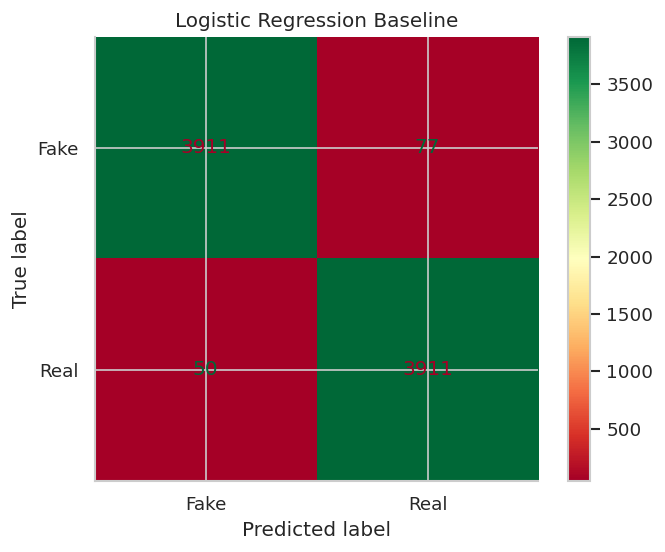

In [ ]:
#______Confusion matrix Logistic Regression Baseline________

cm_lr_baseline = confusion_matrix(
    y_test,
    y_pred_lr_baseline
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr_baseline,
    display_labels=['Fake', 'Real']
)

disp.plot(cmap='RdYlGn')

plt.title("Logistic Regression Baseline")

plt.show()

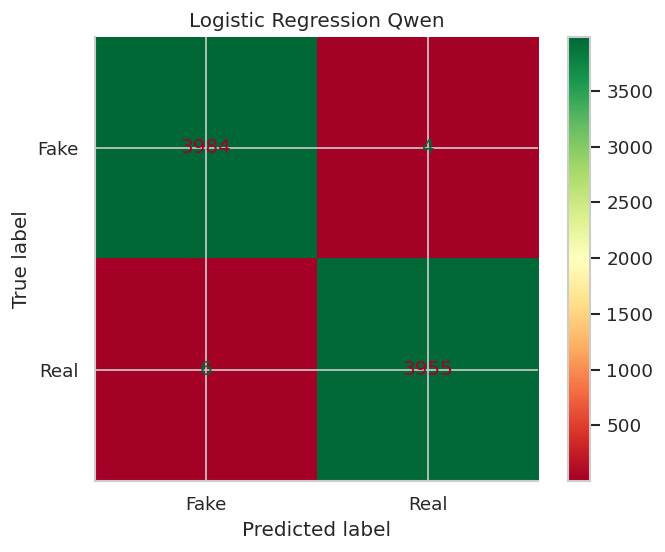

In [ ]:
#______Confusion matrix Logistic regression + Qwen________

cm_lr_qwen = confusion_matrix(
    y_test,
    y_pred_lr_qwen
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr_qwen,
    display_labels=['Fake', 'Real']
)

disp.plot(cmap='RdYlGn')

plt.title("Logistic Regression Qwen")

plt.show()

### Section 6 – Key Takeaways

| Model | Embedding | Accuracy | Notes |
|-------|-----------|------------------|-------|
| Naïve Bayes | TF-IDF | 89.6% | Fast, interpretable; strong baseline |
| Naïve Bayes | Qwen2 | 92.8% | Naïve Bayes struggles with the high dimensionality of Qwen2 |
| Logistic Regression | TF-IDF | 98.4% | Robust linear baseline, as it is a lightweight model |
| **Logistic Regression** | **Qwen2** | **99.9%** | **Best performance overall** - benefits from semantic embeddings |


The **Logistic Regression + Qwen2** combination is selected as the final model. It leverages rich contextual representations from a 1.5 B-parameter transformer and a well calibrated linear classifier. If computational cost is a concern, **Logistic Regression + TF-IDF** is the recommended lightweight alternative with minimal accuracy loss.

## Section 7 - Predictions on unseen dataset

**Objective:** Apply the best-performing model, Qwen2 in combination with Linear Regression classifier, to a held-out validation CSV (`validation_data.csv`) that has no ground-truth labels, and export predictions for submission.

Steps:
1. Load the unseen dataset and create the `content` field (same preprocessing as training).
2. Generate Qwen2 embeddings using the same tokenizer and model (no re-training).
3. Generate prediction using the Linear Regression classifier `lr_qwen` on the unseen set.
4. Export the labelled DataFrame to `validation_data_labeled.csv`.

In [ ]:
dataset_unseen = pd.read_csv('/content/validation_data.csv')

# Concatenate Title and Text
dataset_unseen['content'] = dataset_unseen['title'] + " " + dataset_unseen['text']

# Predictions
X_dataset_unseen = dataset_unseen['content']
X_dataset_unseen = get_qwen_embeddings(X_dataset_unseen.tolist(), batch_size=8)
y_pred_lr_qwen_dataset_unseen = lr_qwen.predict(X_dataset_unseen)

# Label column
dataset_unseen['label'] = y_pred_lr_qwen_dataset_unseen

# Export to CSV file
dataset_unseen.to_csv('validation_data_labeled.csv')

100%|██████████| 620/620 [08:03<00:00,  1.28it/s]


## Section 8 - Conclusions

### Summary

This project tackled the Fake News Detection task using an end-to-end NLP pipeline applied to a balanced dataset of ~40 000 news articles. Four model combinations were evaluated across two embedding strategies and two classifiers.

### Results recap

| Model | Embedding | Accuracy | Notes |
|-------|-----------|------------------|-------|
| Naïve Bayes | TF-IDF | 89.6% | Fast, interpretable; strong baseline |
| Naïve Bayes | Qwen2 | 92.8% | Naïve Bayes struggles with the high dimensionality of Qwen2 |
| Logistic Regression | TF-IDF | 98.4% | Robust linear baseline, as it is a lightweight model |
| **Logistic Regression** | **Qwen2** | **99.9%** | **Best performance overall** - benefits from semantic embeddings |

### Key lessons

1. **Data leakage is the biggest risk** – the `subject` column was a perfect predictor and had to be excluded. Always audit every feature before modelling.
2. **TF-IDF + Naïve Bayes is a remarkably strong baseline** for text classification. It should always be the first model tested before investing in transformer inference.
3. **Qwen2 dense embeddings add value** when the classification task requires understanding semantic nuance beyond vocabulary overlap. Qwen2's contextual representations captured writing style patterns that TF-IDF cannot encode.
4. **Classifier–embedding compatibility** – Logistic Regression was chosen as the primary classifier because it imposes no constraints on the sign or distribution of input features, making it naturally compatible with both the sparse TF-IDF matrix and the signed dense Qwen2 vectors. Its L2 regularisation also prevents overfitting regardless of the feature space dimensionality, making it a robust choice across both embedding strategies.
5. **Final recommendation:** Deploy the **Qwen2 + Logistic Regression** pipeline. If latency or hardware constraints apply, the **TF-IDF + Logistic Regression** model is a production-ready alternative with only a marginal accuracy trade-off.

### Limitations & next steps

- The dataset originates from a specific time window (2015–2018) and political context (US); model generalisation to other languages, domains, or time periods is not guaranteed.
- A **cross-validation** scheme, for example k-fold, would provide more reliable estimates than a single 80/20 split.
- **Hyperparameter optimisation** was not performed on the **classification models**. Both GaussianNB and Logistic Regression were run with default or minimally adjusted settings.
- **Stylometric features** (caps ratio, clickbait score, Reuters prefix, etc.) were computed but not used in the final models. They could further improve performance in a gradient-boosted tree model or as auxiliary inputs to a neural classifier.